# Final comparison


 detector accuracy across **3 rounds of fakes**


need `results_3_rounds.csv` 


## Step 1 — Load all the results

In [1]:
import pandas as pd

df = pd.read_csv("results_3_rounds.csv")
print(df.to_string(index=False))

             classifier  round1_markov  round2_llm_raw  round3_adversarial  drop_markov_to_llm  drop_llm_to_adv  total_drop
        LogReg (TF-IDF)       0.590688          0.4476            0.445683            0.143088         0.001917    0.145005
          Embedding+MLP       0.779223          0.5080            0.474221            0.271223         0.033779    0.305002
                 BiLSTM       0.878900          0.5176            0.438489            0.361300         0.079111    0.440411
  Transformer (scratch)       0.865293          0.5271            0.482734            0.338193         0.044366    0.382559
DistilBERT (fine-tuned)       0.975354          0.5097            0.494245            0.465654         0.015455    0.481109


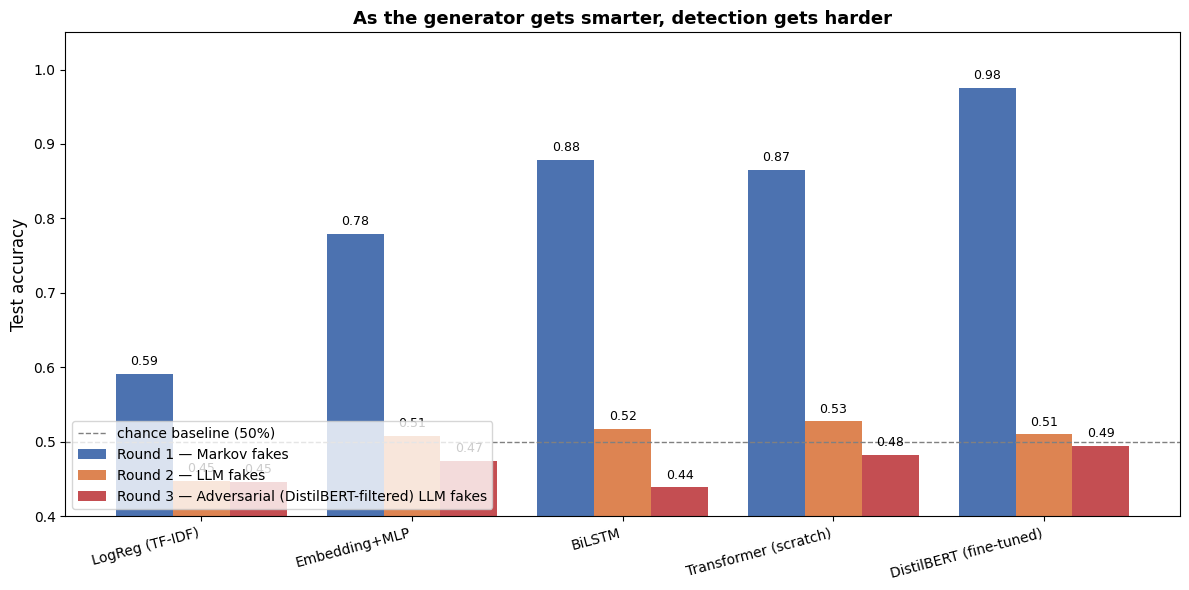

✓ Saved headline_chart.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

names = df["classifier"].tolist()
markov_v = df["round1_markov"].fillna(0).tolist()
llm_v    = df["round2_llm_raw"].fillna(0).tolist()
adv_v    = df["round3_adversarial"].fillna(0).tolist()

x = np.arange(len(names))
w = 0.27

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w, markov_v, w, label="Round 1 — Markov fakes",
            color="#4C72B0")
b2 = ax.bar(x,     llm_v,    w, label="Round 2 — LLM fakes",
            color="#DD8452")
b3 = ax.bar(x + w, adv_v,    w, label="Round 3 — Adversarial (DistilBERT-filtered) LLM fakes",
            color="#C44E52")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0,
           label="chance baseline (50%)")
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_title("As the generator gets smarter, detection gets harder",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.legend(loc="lower left", fontsize=10)

# Value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                    f"{h:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("headline_chart.png", dpi=150)
plt.show()
print("✓ Saved headline_chart.png")

## Per classifier degradation table

This shows how much EACH classifier degrades across the rounds.

In [3]:
# Table
display_df = df[["classifier", "round1_markov", "round2_llm_raw",
                 "round3_adversarial", "total_drop"]].copy()
display_df.columns = ["Classifier", "Markov acc", "LLM acc", "Adversarial acc",
                      "Total drop (R1→R3)"]
print(display_df.to_string(index=False))

             Classifier  Markov acc  LLM acc  Adversarial acc  Total drop (R1→R3)
        LogReg (TF-IDF)    0.590688   0.4476         0.445683            0.145005
          Embedding+MLP    0.779223   0.5080         0.474221            0.305002
                 BiLSTM    0.878900   0.5176         0.438489            0.440411
  Transformer (scratch)    0.865293   0.5271         0.482734            0.382559
DistilBERT (fine-tuned)    0.975354   0.5097         0.494245            0.481109


## A "degradation slope" chart

each classifier as a line, going from round 1 → round 2 → round 3.

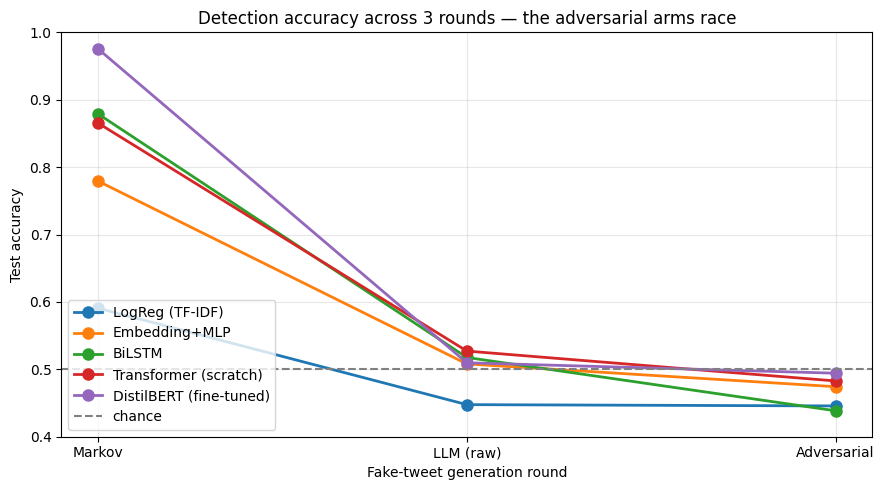

✓ Saved degradation_slope.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
rounds = ["Markov", "LLM (raw)", "Adversarial"]

for _, row in df.iterrows():
    ys = [row["round1_markov"], row["round2_llm_raw"], row["round3_adversarial"]]
    if any(v is None or pd.isna(v) for v in ys):
        continue
    ax.plot(rounds, ys, marker="o", linewidth=2, markersize=8, label=row["classifier"])

ax.axhline(0.5, color="gray", linestyle="--", label="chance")
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Test accuracy")
ax.set_xlabel("Fake-tweet generation round")
ax.set_title("Detection accuracy across 3 rounds — the adversarial arms race")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("degradation_slope.png", dpi=150)
plt.show()
print("✓ Saved degradation_slope.png")